In [47]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.stats import skew, kurtosis


In [48]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/06-new-variables/yellow_tripdata_2024-01.parquet")

# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)

1 files merged
(2533274, 25)


In [49]:
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_hr'] = df['tpep_pickup_datetime'].dt.hour
df['weekday'] = df['tpep_pickup_datetime'].dt.weekday # monday = 0, sunday = 6

df['dropoff_day'] = df['tpep_dropoff_datetime'].dt.day
df['dropoff_hr'] = df['tpep_dropoff_datetime'].dt.hour

df['revenue'] = df['fare_amount'] + df['tip_amount']

df.head(2)

,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,ratecode,payment_type,fare_amount,extra,mta_tax,tip_amount,...,pickup_hour,hour_bin,log_trip_distance,total_amount_calculated,pickup_day,pickup_hr,weekday,dropoff_day,dropoff_hr,revenue
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,Standard rate,Cash,17.70,1.00,0.50,0.00,...,0,0-2,1.00,22.70,1,0,0,1,1,17.70
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,Standard rate,Credit card,10.00,3.50,0.50,3.75,...,0,0-2,1.03,21.25,1,0,0,1,0,13.75


In [50]:
df_filt = df[['pickup_day', 'pickup_hr', 'weekday', 'pickup_zone']]
df_filt.head(2)

,pickup_day,pickup_hr,weekday,pickup_zone
0,1,0,0,Penn Station/Madison Sq West
1,1,0,0,Lenox Hill East


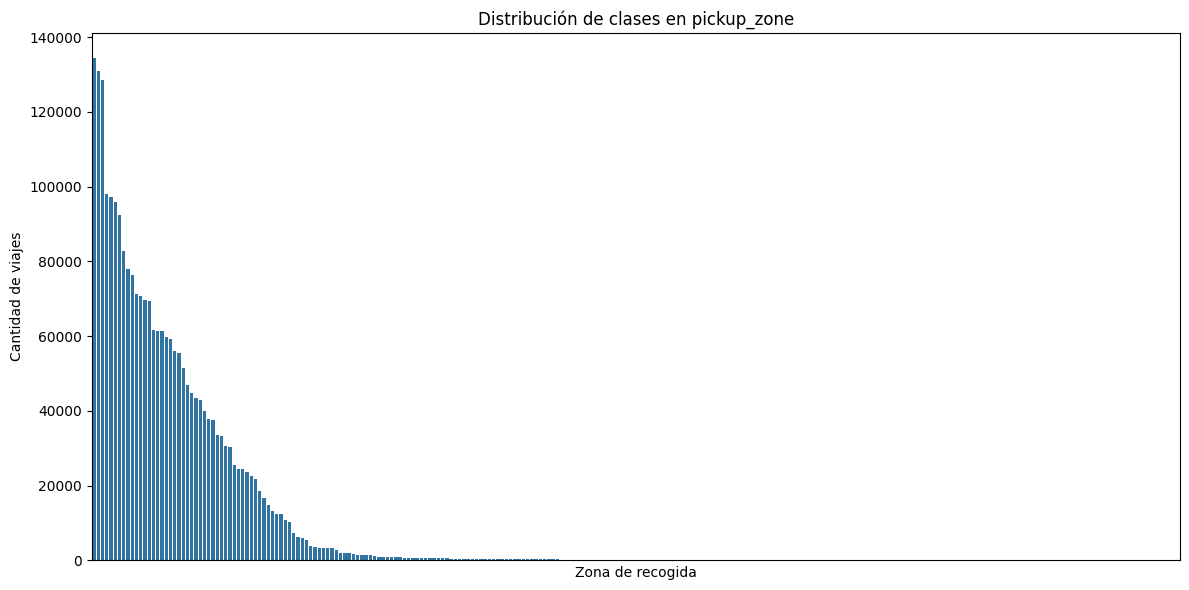

In [51]:
# balance de clases (target='pickup_zone')
plt.figure(figsize=(12,6))
sns.countplot(data=df_filt, x='pickup_zone', order=df_filt['pickup_zone'].value_counts().index)
plt.title('Distribución de clases en pickup_zone')
plt.xlabel('Zona de recogida')
plt.ylabel('Cantidad de viajes')
# deshabilitar etiquetas de datos en eje x
plt.xticks([], [])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [53]:
# indice de gini para el dataset balanceado y no balanceado
def gini_index(counts):
    proportions = counts / counts.sum()
    gini = 1 - np.sum(proportions ** 2)
    return gini
gini_before = gini_index(df['pickup_zone'].value_counts())
print(f"Índice de Gini antes del balanceo: {gini_before:.4f}")

Índice de Gini antes del balanceo: 0.9726


In [55]:
# entropia de shannon para el dataset balanceado y no balanceado
def shannon_entropy(counts):
    proportions = counts / counts.sum()
    entropy = -np.sum(proportions * np.log2(proportions + 1e-9))  # agregar un pequeño valor para evitar log(0)
    return entropy
entropy_before = shannon_entropy(df['pickup_zone'].value_counts())
print(f"Entropía de Shannon antes del balanceo: {entropy_before:.4f}")

Entropía de Shannon antes del balanceo: 5.5419


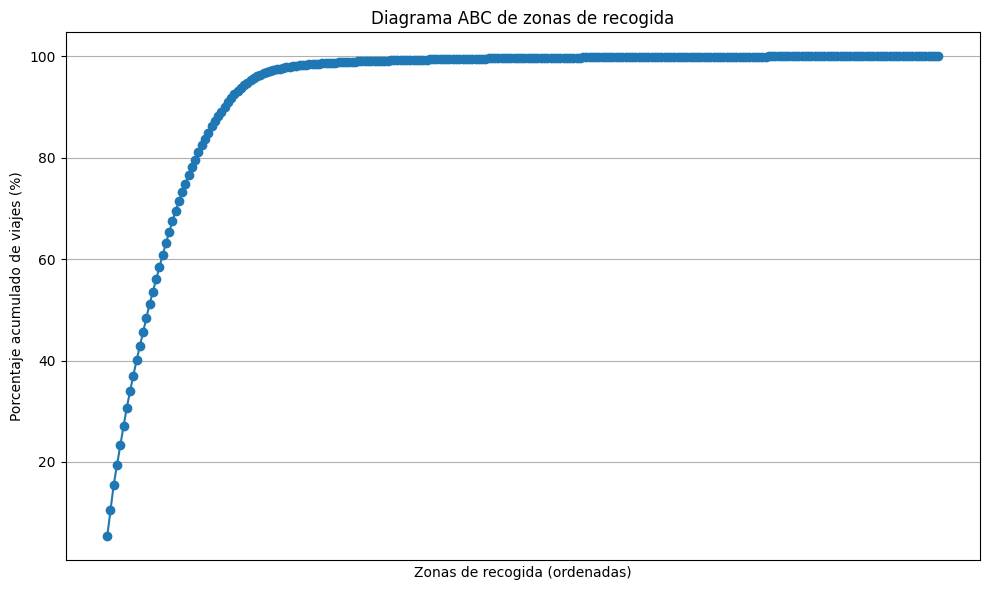

In [31]:
# diagrama abc de clases 
zone_counts = df_filt['pickup_zone'].value_counts().sort_values(ascending=False)
zone_cumperc = zone_counts.cumsum() / zone_counts.sum() * 100
plt.figure(figsize=(10,6))
plt.plot(zone_cumperc.index, zone_cumperc.values, marker='o')
plt.title('Diagrama ABC de zonas de recogida')
plt.xlabel('Zonas de recogida (ordenadas)')
plt.ylabel('Porcentaje acumulado de viajes (%)')
plt.grid()
plt.xticks([], [])
plt.tight_layout()
plt.show()

In [32]:
# filtramos zonas hasta cubrir el 99% de los viajes
threshold = 99.0
zones_to_keep = zone_cumperc[zone_cumperc <= threshold].index
df_balanced = df_filt[df_filt['pickup_zone'].isin(zones_to_keep)].copy()
print(f"Zonas retenidas: {len(zones_to_keep)} de {len(zone_counts)}")
print(f"Cantidad de viajes después del balanceo: {len(df_balanced)} de {len(df_filt)}")
df_balanced.head(2)


Zonas retenidas: 78 de 256
Cantidad de viajes después del balanceo: 2507626 de 2533274


,pickup_day,pickup_hr,weekday,pickup_zone
0,1,0,0,Penn Station/Madison Sq West
1,1,0,0,Lenox Hill East


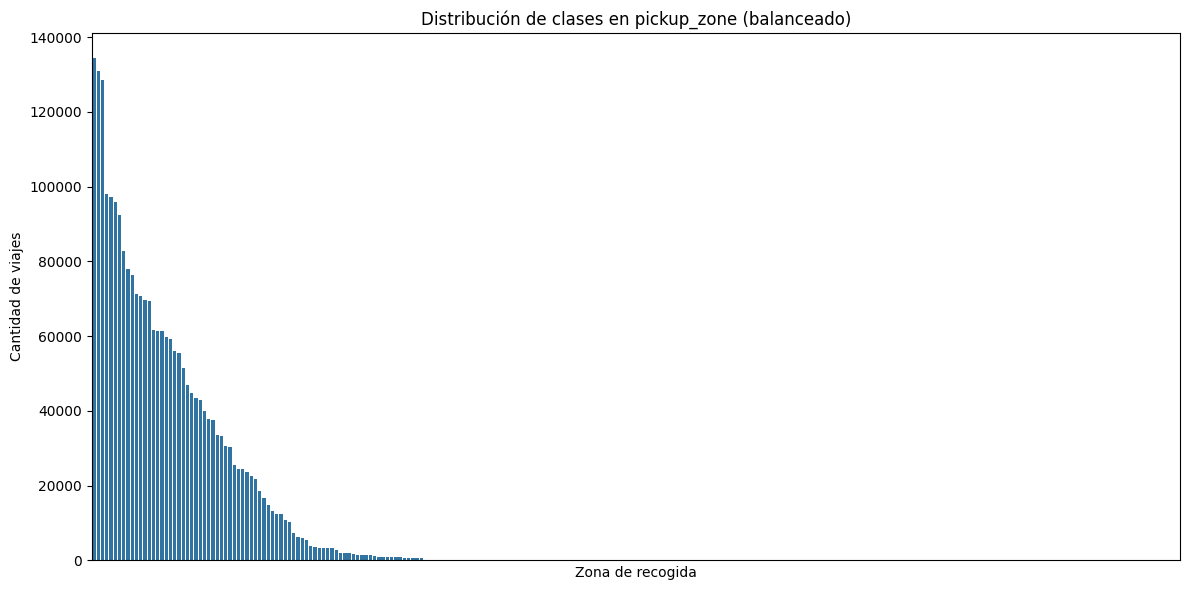

In [33]:
# grafico de clases balanceadas
plt.figure(figsize=(12,6))
sns.countplot(data=df_balanced, x='pickup_zone', order=df_balanced['pickup_zone'].value_counts().index)
plt.title('Distribución de clases en pickup_zone (balanceado)')
plt.xlabel('Zona de recogida')
plt.ylabel('Cantidad de viajes')
# deshabilitar etiquetas de datos en eje x
plt.xticks([], [])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [39]:
# indice de gini para el dataset balanceado y no balanceado
def gini_index(counts):
    proportions = counts / counts.sum()
    gini = 1 - np.sum(proportions ** 2)
    return gini
gini_before = gini_index(df['pickup_zone'].value_counts())
gini_after = gini_index(df_balanced['pickup_zone'].value_counts())
print(f"Índice de Gini antes del balanceo: {gini_before:.4f}")
print(f"Índice de Gini después del balanceo: {gini_after:.4f}")


Índice de Gini antes del balanceo: 0.9726
Índice de Gini después del balanceo: 0.9720


In [56]:
# entropia de shannon para el dataset balanceado y no balanceado

entropy_before = shannon_entropy(df['pickup_zone'].value_counts())
print(f"Entropía de Shannon antes del balanceo: {entropy_before:.4f}")
entropy_after = shannon_entropy(df_balanced['pickup_zone'].value_counts())
print(f"Entropía de Shannon después del balanceo: {entropy_after:.4f}")


Entropía de Shannon antes del balanceo: 5.5419
Entropía de Shannon después del balanceo: 5.4468


In [83]:
n_samples_per_class = 1500

df_sampled = (
    df_filt
    .dropna(subset=['pickup_zone'])
    .groupby('pickup_zone')
    .apply(lambda x: x.sample(
        n=min(len(x), n_samples_per_class),
        replace=False
    ))
    .reset_index(drop=True)
)


/tmp/ipykernel_14419/3427515433.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('pickup_zone')
/tmp/ipykernel_14419/3427515433.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [84]:
# entropia de shannon para el dataset balanceado y no balanceado
def shannon_entropy(counts):
    proportions = counts / counts.sum()
    entropy = -np.sum(proportions * np.log2(proportions + 1e-9))  # agregar un pequeño valor para evitar log(0)
    return entropy
entropy_before = shannon_entropy(df['pickup_zone'].value_counts())
print(f"Entropía de Shannon antes del balanceo: {entropy_before:.4f}")
entropy_after = shannon_entropy(df_balanced['pickup_zone'].value_counts())
print(f"Entropía de Shannon después del balanceo: {entropy_after:.4f}")
entropy_sampled = shannon_entropy(df_sampled['pickup_zone'].value_counts())
print(f"Entropía de Shannon después del balanceo por muestreo: {entropy_sampled:.4f}")
# maximo teorico de entropia 
print(f"Entropía de Shannon máxima teórica: {np.log2(len(df_sampled['pickup_zone'].unique())):.4f}")

Entropía de Shannon antes del balanceo: 5.5419
Entropía de Shannon después del balanceo: 5.4468
Entropía de Shannon después del balanceo por muestreo: 7.0630
Entropía de Shannon máxima teórica: 7.9658


In [88]:
# filtramos filas con clases con registros <2 
df_sampled = df_sampled.groupby('pickup_zone').filter(lambda x: len(x) >= 2)

/tmp/ipykernel_14419/2459479768.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sampled = df_sampled.groupby('pickup_zone').filter(lambda x: len(x) >= 2)


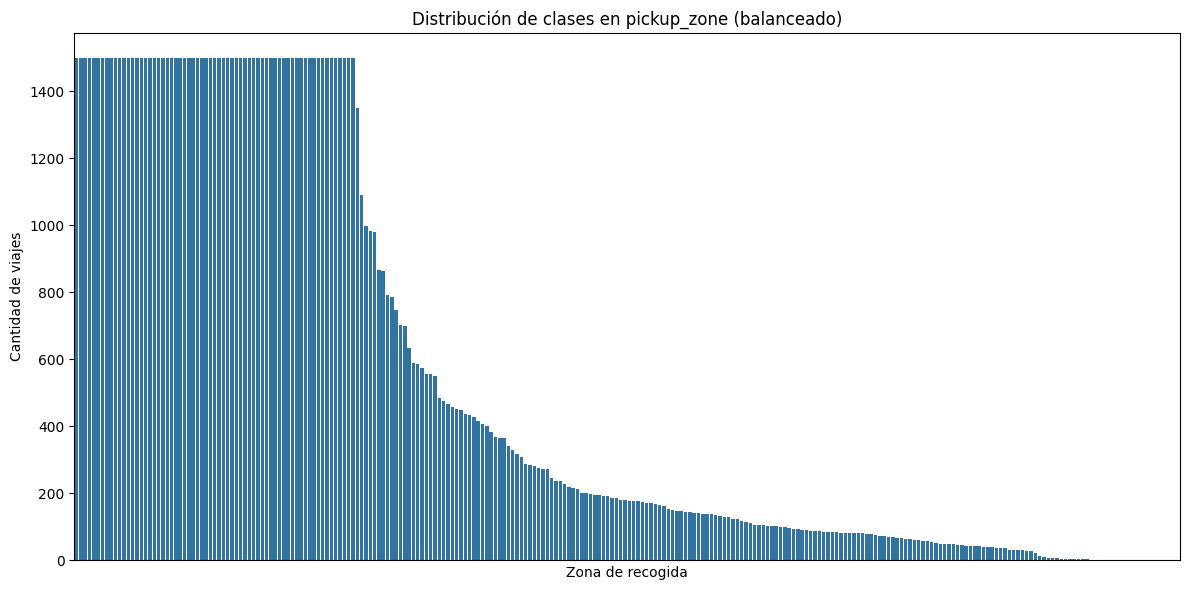

In [89]:
# grafico de clases balanceadas
plt.figure(figsize=(12,6))
sns.countplot(data=df_sampled, x='pickup_zone', order=df_sampled['pickup_zone'].value_counts().index)
plt.title('Distribución de clases en pickup_zone (balanceado)')
plt.xlabel('Zona de recogida')
plt.ylabel('Cantidad de viajes')
# deshabilitar etiquetas de datos en eje x
plt.xticks([], [])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [101]:
# agregamos columna de frecuencia por hora, zona, dia y dia de la semana
df_sampled['freq_zone_hr_day_wk'] = df_sampled.groupby(['pickup_zone', 'pickup_hr', 'pickup_day', 'weekday'])['pickup_zone'].transform('count')

/tmp/ipykernel_14419/3034465755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sampled['freq_zone_hr_day_wk'] = df_sampled.groupby(['pickup_zone', 'pickup_hr', 'pickup_day', 'weekday'])['pickup_zone'].transform('count')


In [102]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# Separar X e y
X = df_sampled.drop(columns=['pickup_zone'])
y = df_sampled['pickup_zone']

# Codificar clases (OBLIGATORIO para XGBoost multiclase)
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, 
    test_size=0.2, 
    stratify=y_enc,
    random_state=42
)


In [103]:
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_train)),
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',   # MUY rápido
    n_jobs=-1,
    random_state=42
)


In [107]:
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)


[0]	validation_0-mlogloss:5.33625
[10]	validation_0-mlogloss:4.75308
[20]	validation_0-mlogloss:4.53148
[30]	validation_0-mlogloss:4.40995
[40]	validation_0-mlogloss:4.33657
[50]	validation_0-mlogloss:4.28487
[60]	validation_0-mlogloss:4.24711
[70]	validation_0-mlogloss:4.21525
[80]	validation_0-mlogloss:4.19004
[90]	validation_0-mlogloss:4.16763
[100]	validation_0-mlogloss:4.14901
[110]	validation_0-mlogloss:4.13261
[120]	validation_0-mlogloss:4.11699
[130]	validation_0-mlogloss:4.10324
[140]	validation_0-mlogloss:4.09144
[150]	validation_0-mlogloss:4.08086
[160]	validation_0-mlogloss:4.07104
[170]	validation_0-mlogloss:4.06214
[180]	validation_0-mlogloss:4.05394
[190]	validation_0-mlogloss:4.04579
[199]	validation_0-mlogloss:4.03904


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [108]:
y_pred = model.predict(X_test)
0
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print(classification_report(y_test, y_pred))


Accuracy: 0.1077
              precision    recall  f1-score   support

           0       0.06      0.08      0.07        13
           1       0.75      0.38      0.51       300
           2       0.00      0.00      0.00         1
           3       0.21      0.13      0.16       300
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00        62
           7       0.00      0.00      0.00         6
           8       0.13      0.19      0.15       150
           9       0.14      0.11      0.12       300
          10       0.05      0.07      0.06        40
          11       0.00      0.00      0.00         5
          12       0.00      0.00      0.00        10
          13       0.03      0.04      0.04        90
          14       0.00      0.00      0.00        21
          15       0.00      0.00      0.00         9
          16       0.00      0.00      0.00        18
          

/home/gaspi/CEIA_AndD_TP_Grupo2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gaspi/CEIA_AndD_TP_Grupo2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gaspi/CEIA_AndD_TP_Grupo2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [109]:
probas = model.predict_proba(X_test)
top5 = np.argsort(probas, axis=1)[:, -5:]

top5_acc = np.mean([
    y_test[i] in top5[i]
    for i in range(len(y_test))
])

print("Top-5 Accuracy:", top5_acc)


Top-5 Accuracy: 0.26240344622697565
